In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mlt

In [50]:
history_df=pd.read_csv("historical_data.csv")
greed_df=pd.read_csv("fear_greed_index.csv")



In [51]:
history_df["date"]=pd.to_datetime(history_df["Timestamp"],unit="ms")

In [52]:
history_df.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20


In [53]:
greed_df.head(2)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02


In [54]:
greed_df.duplicated().sum()

np.int64(0)

In [55]:
greed_df = greed_df.drop("timestamp", axis=1)


In [56]:
greed_df

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05
...,...,...,...
2639,54,Neutral,2025-04-28
2640,60,Greed,2025-04-29
2641,56,Greed,2025-04-30
2642,53,Neutral,2025-05-01


In [57]:
history_df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-06-15 15:06:40
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-06-15 15:06:40
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-06-15 15:06:40
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-06-15 15:06:40


In [60]:
history_df["date"] = pd.to_datetime(history_df["date"]).dt.strftime('%Y-%m-%d')


In [66]:
merged_df=pd.merge(history_df,greed_df,on="date",how="inner")

In [67]:
merged_df.shape

(184263, 19)

In [68]:
merged_df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,74,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184258,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,4.13,551.77,BUY,18-04-2025 20:03,-1797.880000,Close Short,-82.883731,0xbbde0f181b617f8d2e2a0421c9a82a02077000c2d6ba...,87333347541,False,0.055176,6.900000e+14,1.740000e+12,2025-02-19,44,Fear
184259,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,7.50,1002.00,BUY,18-04-2025 20:03,-1793.750000,Close Short,-150.515250,0x6bd337120e6f682326d30421c9a82a02077100566072...,87333347541,False,0.100200,6.610000e+13,1.740000e+12,2025-02-19,44,Fear
184260,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,3.93,525.05,BUY,18-04-2025 20:03,-1786.250000,Close Short,-78.869991,0xdbff44ed44a78acf124c0421c9a82a0207720000b450...,87333347541,False,0.052504,1.010000e+15,1.740000e+12,2025-02-19,44,Fear
184261,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.6000,4.34,579.82,BUY,18-04-2025 20:03,-1782.320000,Close Short,-87.098158,0xd8f4fcfddd57c09658a90421c9a82a0207780007b85e...,87333347541,False,0.057982,2.700000e+13,1.740000e+12,2025-02-19,44,Fear


In [74]:
merged_df["profitable"]=(merged_df["Closed PnL"]>0).astype(float)

In [79]:
(merged_df["profitable"]>0.0).sum()
(merged_df["profitable"]>0.0).count()

np.int64(184263)

In [88]:
Daily_per_account_metrics=merged_df.groupby(["Account","date"]).agg(
    sum_pnl=("Closed PnL","sum"),
    avg_pnl=("Closed PnL","mean"),
    win_rate=("profitable","mean"),
    total_volume=("Size Tokens","sum")



).reset_index()

In [89]:
Daily_per_account_metrics

,Account,date,sum_pnl,avg_pnl,win_rate,total_volume
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,-708.887230,0.025974,5.681000e+03
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,574.414696,0.405542,5.604539e+04
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,64.398269,0.531250,4.145268e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,4.839719,0.435041,3.009395e+06
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,-0.200000,0.000000,2.000000e+02
...,...,...,...,...,...,...
72,0xbaaaf6571ab7d571043ff1e313a9609a10637864,2025-02-19,9.401572e+05,44.367967,0.467532,4.425939e+06
73,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2024-10-27,1.167168e+04,43.714157,0.153558,5.170020e+05
74,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-02-19,3.254420e+05,147.192210,0.372230,9.560620e+06
75,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2024-10-27,6.842150e+05,69.231509,0.569260,1.083109e+06


In [97]:
Daily_global_metrics=merged_df.groupby(
    "date"
).agg(
    total_trades=("Order ID","count"),
    unique_traders=("Account","nunique"),
    
    avg_pnl=("Closed PnL","mean"),
     win_rate=("profitable","mean"),
     total_volume=("Size Tokens","sum")

).reset_index()

In [98]:
Daily_global_metrics

,date,total_trades,unique_traders,avg_pnl,win_rate,total_volume
0,2023-03-28,3,1,0.000000,0.000000,2.513000e-01
1,2023-11-14,1045,2,0.148807,0.274641,2.681692e+06
2,2024-03-09,6962,5,25.418772,0.490089,3.393031e+08
3,2024-07-03,7141,8,22.229713,0.317182,1.404851e+07
4,2024-10-27,35241,29,90.504272,0.451605,7.831963e+07
5,2025-02-19,133871,32,50.047622,0.415146,4.111879e+08


4️⃣ Merge trader metrics with sentiment

Use the date column in both datasets

Example:

merged = daily_trader_metrics.merge(fg[['date','classification','value']], on='date', how='inner')


Now each row has daily trader metrics + Fear/Greed sentiment.

In [99]:
# Merge sentiment into the per-account daily metrics
daily_account_sentiment = Daily_per_account_metrics.merge(
    greed_df[['date', 'classification', 'value']], 
    on='date', 
    how='inner'
)

# Merge sentiment into the global daily metrics
daily_global_sentiment = Daily_global_metrics.merge(
    greed_df[['date', 'classification', 'value']], 
    on='date', 
    how='inner'
)

# Let's peek at the final result!
daily_global_sentiment.head()


,date,total_trades,unique_traders,avg_pnl,win_rate,total_volume,classification,value
0,2023-03-28,3,1,0.000000,0.000000,2.513000e-01,Greed,59
1,2023-11-14,1045,2,0.148807,0.274641,2.681692e+06,Greed,69
2,2024-03-09,6962,5,25.418772,0.490089,3.393031e+08,Extreme Greed,84
3,2024-07-03,7141,8,22.229713,0.317182,1.404851e+07,Neutral,50
4,2024-10-27,35241,29,90.504272,0.451605,7.831963e+07,Greed,74


In [104]:
import matplotlib.pyplot as plt

C:\Users\Krish Sharma\AppData\Local\Temp\ipykernel_17640\1025037919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


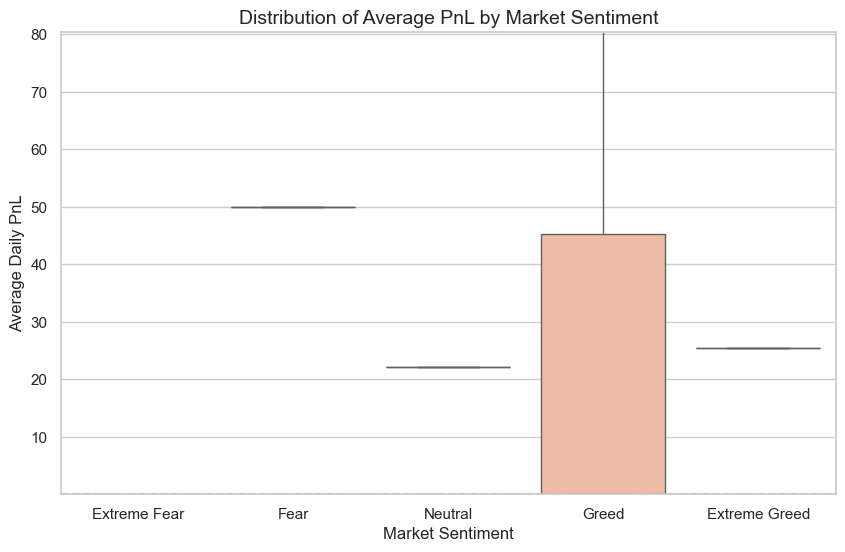

In [105]:
plt.figure(figsize=(10, 6))
category_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

# Boxplot of avg_pnl by classification
sns.boxplot(
    data=daily_global_sentiment, 
    x="classification", 
    y="avg_pnl", 
    order=category_order,
    palette="coolwarm"
)

# Optional: Zoom in slightly to see the boxes better since crypto PnL can have huge outliers
plt.ylim(daily_global_sentiment['avg_pnl'].quantile(0.05), daily_global_sentiment['avg_pnl'].quantile(0.95))

plt.title("Distribution of Average PnL by Market Sentiment", fontsize=14)
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Average Daily PnL", fontsize=12)
plt.axhline(0, color="red", linestyle="--", alpha=0.5) # Add a break-even line
plt.show()


C:\Users\Krish Sharma\AppData\Local\Temp\ipykernel_17640\1913380254.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


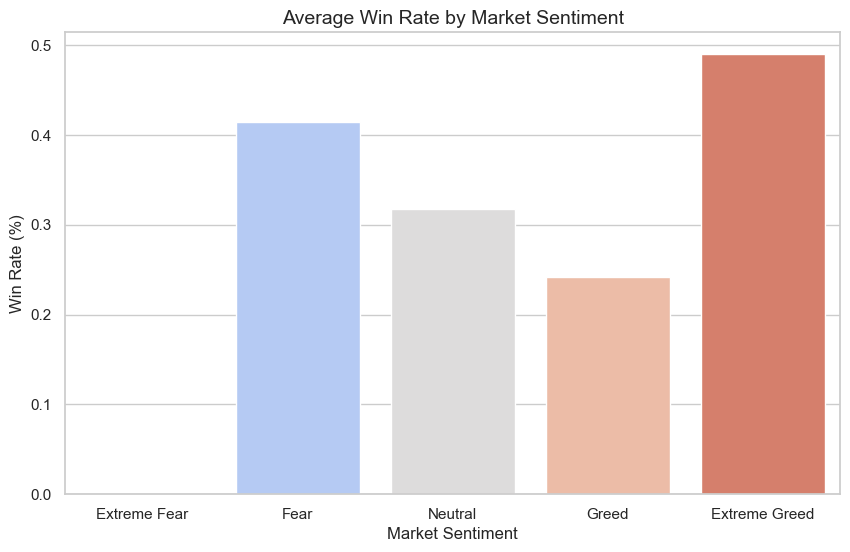

In [106]:
plt.figure(figsize=(10, 6))

# Bar chart of win rate by sentiment
sns.barplot(
    data=daily_global_sentiment, 
    x="classification", 
    y="win_rate", 
    order=category_order,
    palette="coolwarm",
    errorbar=None # Turns off error bars for a cleaner look
)

plt.title("Average Win Rate by Market Sentiment", fontsize=14)
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Win Rate (%)", fontsize=12)
plt.show()


C:\Users\Krish Sharma\AppData\Local\Temp\ipykernel_17640\1105175984.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


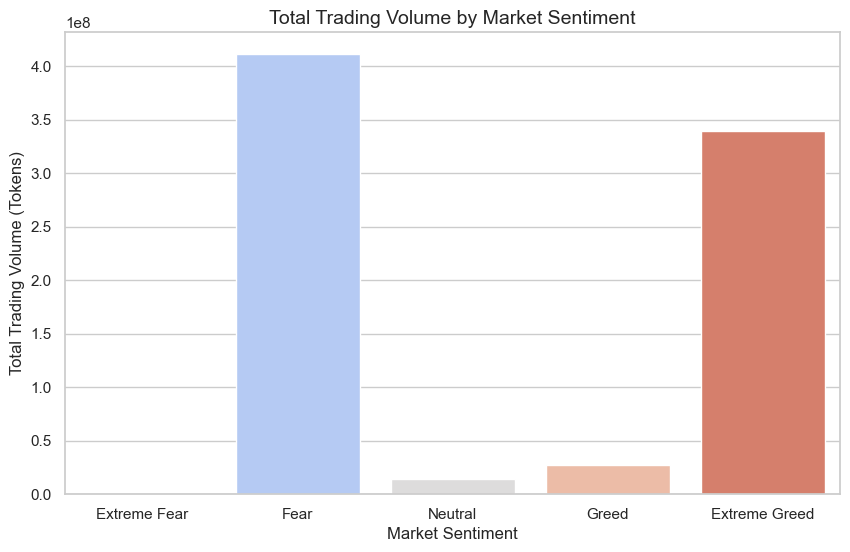

In [107]:
plt.figure(figsize=(10, 6))

# Volume by sentiment
sns.barplot(
    data=daily_global_sentiment, 
    x="classification", 
    y="total_volume", 
    order=category_order,
    palette="coolwarm",
    errorbar=None
)

plt.title("Total Trading Volume by Market Sentiment", fontsize=14)
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Total Trading Volume (Tokens)", fontsize=12)
plt.show()


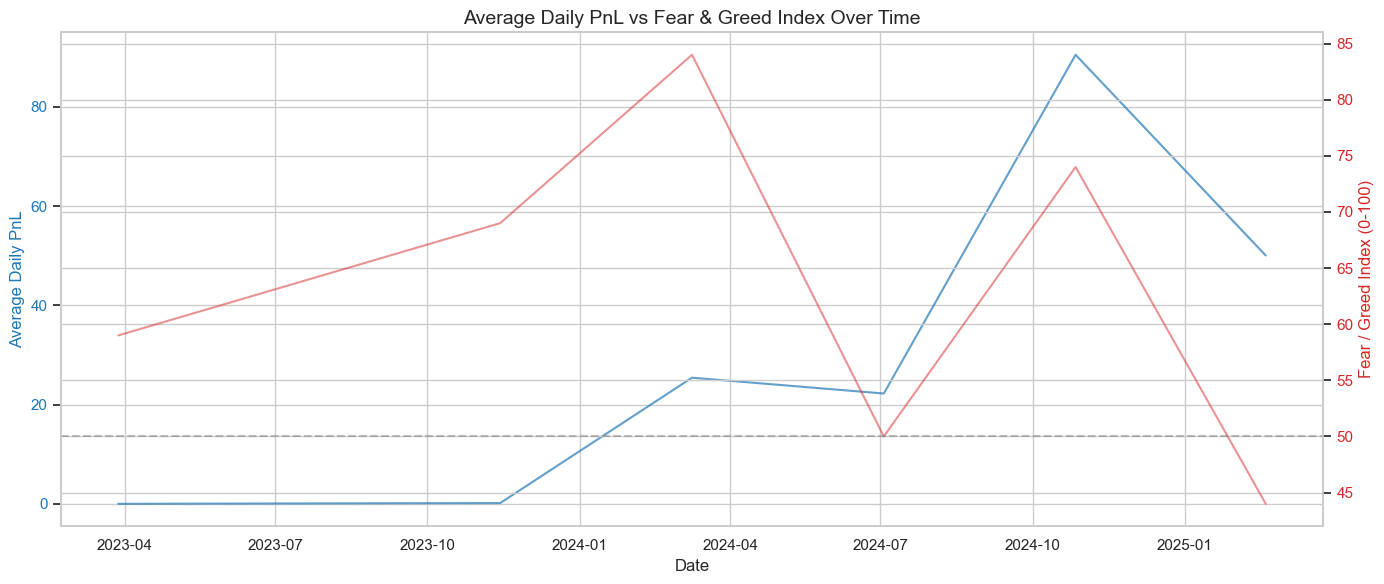

In [108]:
# Convert date back to a datetime object just for sorting/plotting purposes
daily_global_sentiment['date'] = pd.to_datetime(daily_global_sentiment['date'])
daily_global_sentiment = daily_global_sentiment.sort_values('date')

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Average PnL on the primary y-axis (left)
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Daily PnL', color=color)
ax1.plot(daily_global_sentiment['date'], daily_global_sentiment['avg_pnl'], color=color, alpha=0.7, label='Avg PnL')
ax1.tick_params(axis='y', labelcolor=color)

# Create a secondary y-axis for the Fear/Greed Index
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Fear / Greed Index (0-100)', color=color)  
ax2.plot(daily_global_sentiment['date'], daily_global_sentiment['value'], color=color, alpha=0.5, label='F&G Index')
ax2.tick_params(axis='y', labelcolor=color)

# Add a dashed line at 50 for the fear/greed midpoint
ax2.axhline(50, color='gray', linestyle='dashed', alpha=0.5)

plt.title("Average Daily PnL vs Fear & Greed Index Over Time", fontsize=14)
fig.tight_layout() 
plt.show()


In [110]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [111]:
# Drop any rows with NaN in avg_pnl or classification to be safe
anova_data = daily_global_sentiment.dropna(subset=['avg_pnl', 'classification'])

# Group the PnL data based on the 5 Fear/Greed classifications
extreme_fear = anova_data[anova_data['classification'] == 'Extreme Fear']['avg_pnl']
fear = anova_data[anova_data['classification'] == 'Fear']['avg_pnl']
neutral = anova_data[anova_data['classification'] == 'Neutral']['avg_pnl']
greed = anova_data[anova_data['classification'] == 'Greed']['avg_pnl']
extreme_greed = anova_data[anova_data['classification'] == 'Extreme Greed']['avg_pnl']

# Perform One-Way ANOVA
f_stat, p_val = stats.f_oneway(extreme_fear, fear, neutral, greed, extreme_greed)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: There is a statistically significant difference in avg_pnl across different sentiment categories.")
else:
    print("Conclusion: No statistically significant difference in avg_pnl across sentiment categories was found.")


ANOVA F-statistic: nan
ANOVA p-value: nan
Conclusion: No statistically significant difference in avg_pnl across sentiment categories was found.


C:\Users\Krish Sharma\AppData\Local\Temp\ipykernel_17640\626543369.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = stats.f_oneway(extreme_fear, fear, neutral, greed, extreme_greed)


In [112]:
# Perform Tukey's HSD to compare all groups against each other
tukey_results = pairwise_tukeyhsd(endog=anova_data['avg_pnl'], 
                                  groups=anova_data['classification'], 
                                  alpha=0.05)

print(tukey_results)


      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1     group2 meandiff p-adj    lower    upper   reject
---------------------------------------------------------------
Extreme Greed    Fear  24.6288  0.984 -486.9247 536.1824  False
Extreme Greed   Greed   4.7989 0.9998 -412.8828 422.4807  False
Extreme Greed Neutral  -3.1891    1.0 -514.7427 508.3645  False
         Fear   Greed -19.8299 0.9846 -437.5117 397.8518  False
         Fear Neutral -27.8179 0.9775 -539.3715 483.7357  False
        Greed Neutral   -7.988 0.9989 -425.6697 409.6938  False
---------------------------------------------------------------


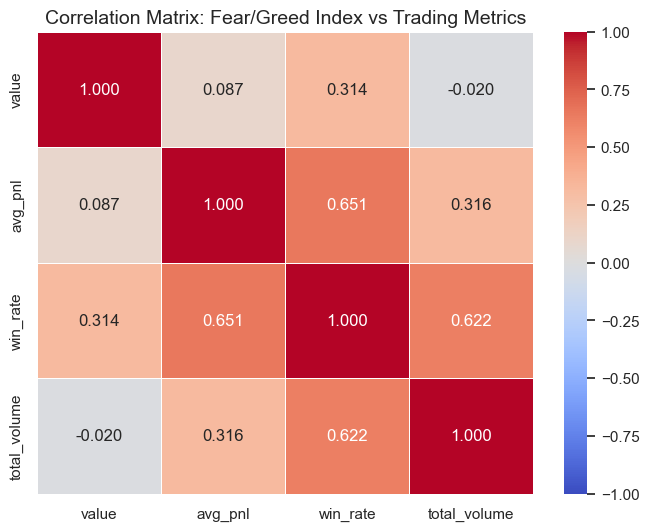

Correlation with Fear/Greed Index (0-100):
vs Avg PnL:      0.0874
vs Win Rate:     0.3143
vs Total Volume: -0.0196


In [113]:
# Select only the numeric columns of interest
correlation_vars = ['value', 'avg_pnl', 'win_rate', 'total_volume']

# Calculate the correlation matrix
corr_matrix = daily_global_sentiment[correlation_vars].corr()

# Let's visualize it with a heatmap so it's easy to read!
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f", linewidths=.5)
plt.title("Correlation Matrix: Fear/Greed Index vs Trading Metrics", fontsize=14)
plt.show()

# Print specific correlations against the F&G 'value'
print("Correlation with Fear/Greed Index (0-100):")
print(f"vs Avg PnL:      {corr_matrix.loc['value', 'avg_pnl']:.4f}")
print(f"vs Win Rate:     {corr_matrix.loc['value', 'win_rate']:.4f}")
print(f"vs Total Volume: {corr_matrix.loc['value', 'total_volume']:.4f}")


--- Random Forest Regression Results ---
Mean Squared Error (MSE): 1971.3294
R-squared (R2 Score):     -356099.2158
--------------------------------------


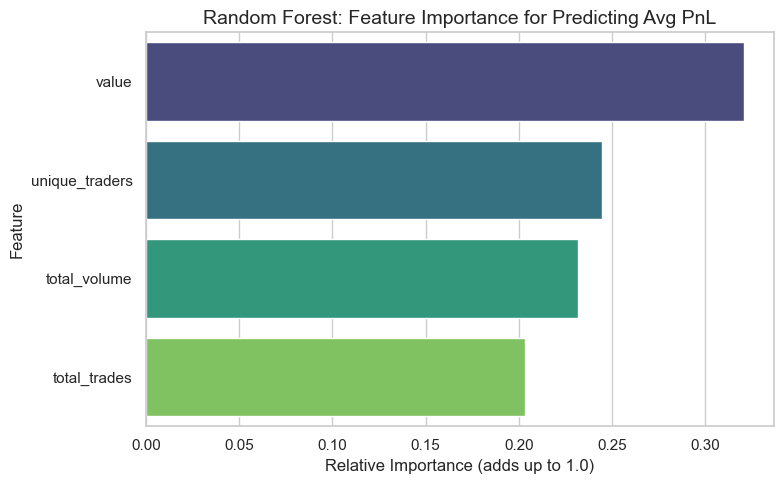

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Features (X) and Target (y)
# 'value' is the numeric Fear/Greed Index sentiment score
features = ['total_trades', 'unique_traders', 'total_volume', 'value']

# Drop any rows with missing data just in case
ml_df = daily_global_sentiment.dropna(subset=features + ['avg_pnl'])

X = ml_df[features]
y = ml_df['avg_pnl'] # You can change this to 'win_rate' to predict win rate instead!

# 2. Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = rf_model.predict(X_test)

# 5. Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Random Forest Regression Results ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2 Score):     {r2:.4f}")
print("-" * 38)
# Note: An R2 of 1.0 is perfect prediction. 0.0 is predicting essentially random noise.

# 6. Extract and Plot Feature Importance
feature_importances = rf_model.feature_importances_

# Create a DataFrame for neat visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)

plt.title('Random Forest: Feature Importance for Predicting Avg PnL', fontsize=14)
plt.xlabel('Relative Importance (adds up to 1.0)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()


In [117]:
# 1. Group by account to get overall historical performance
account_performance = daily_account_sentiment.groupby('Account').agg(
    total_pnl=('sum_pnl', 'sum'),
    overall_win_rate=('win_rate', 'mean'),
    days_traded=('date', 'nunique')
).reset_index()

# Sort by total PnL to find the whales and the losers
account_performance = account_performance.sort_values(by='total_pnl', ascending=False)

# Get Top 5 Performers
top_5 = account_performance.head(5)
print("--- Top 5 Performing Accounts ---")
display(top_5)

# Get Bottom 5 Performers
bottom_5 = account_performance.tail(5)
print("\n--- Bottom 5 Performing Accounts ---")
display(bottom_5)

# 2. Deep Dive: Look at the #1 Top Performer during different sentiments
# Get the Account address of the #1 trader
best_account = top_5.iloc[0]['Account']

# Filter the daily account data for just this trader
best_trader_data = daily_account_sentiment[daily_account_sentiment['Account'] == best_account]

# Average daily PnL of the best trader grouped by sentiment
best_trader_by_sentiment = best_trader_data.groupby('classification')[['sum_pnl', 'win_rate']].mean().reset_index()

print(f"\n--- Best Trader ({best_account[:8]}...) Performance by Market Sentiment ---")
display(best_trader_by_sentiment)


--- Top 5 Performing Accounts ---


,Account,total_pnl,overall_win_rate,days_traded
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.040922e+06,0.332406,5
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.215758,2
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401572e+05,0.467532,1
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.111830e+05,0.477062,2
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.744040e+05,0.453428,2



--- Bottom 5 Performing Accounts ---


,Account,total_pnl,overall_win_rate,days_traded
28,0xb899e522b5715391ae1d4f137653e7906c5e2115,22488.500821,0.438611,1
26,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,21758.831753,0.273016,2
18,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,14781.443047,0.451094,1
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,14456.919336,0.423541,2
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-27704.567439,0.194149,6



--- Best Trader (0xb1231a...) Performance by Market Sentiment ---


,classification,sum_pnl,win_rate
0,Extreme Greed,2606.894756,0.218791
1,Fear,553818.000465,0.391057
2,Greed,710955.674614,0.421101
3,Neutral,62586.181600,0.209982
